In [1]:
!pip uninstall -y transformers peft trl accelerate
!pip install -q \
transformers==4.52.4 \
peft==0.17.1 \
trl==0.19.1 \
accelerate==1.7.0

Found existing installation: transformers 5.12.0
Uninstalling transformers-5.12.0:
  Successfully uninstalled transformers-5.12.0
Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
Found existing installation: accelerate 1.14.0
Uninstalling accelerate-1.14.0:
  Successfully uninstalled accelerate-1.14.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.2/376.2 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.1/362.1 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 104.3 MB/s eta 0:00:00


In [2]:
import json

data = [
    {
        "messages": [
            {"role":"user","content":"What is Biplov City?"},
            {"role":"assistant","content":"Biplov City is a fictional smart city in Nepal with 10 million solar-powered flying cars."}
        ]
    }
]

with open("nepal_tourism.jsonl", "w") as f:
    for row in data:
        f.write(json.dumps(row) + "\n")

In [3]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="nepal_tourism.jsonl"
)

Generating train split: 0 examples [00:00, ? examples/s]

In [4]:
def format_example(example):
    text = ""

    for msg in example["messages"]:
        text += f"{msg['role']}: {msg['content']}\n"

    return {"text": text}

dataset = dataset.map(format_example)

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

tokenizer.pad_token = tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [6]:
import transformers
print(transformers.__version__)

4.52.4


In [23]:
from peft import LoraConfig

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ]
)

In [31]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./tinyllama-output",
    num_train_epochs=25,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    logging_steps=1,
    save_strategy="epoch",
    fp16=True,
    report_to="none"
)

In [32]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset["train"],
    peft_config=peft_config,
    args=training_args
)

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [33]:
model = trainer.model

In [34]:
trainer.train()

Step,Training Loss
1,1.457200
2,1.346400
3,1.235600
4,1.119900
5,1.002600
6,0.898000
7,0.804400
8,0.724000
9,0.644200
10,0.578100


TrainOutput(global_step=25, training_loss=0.6162230014801026, metrics={'train_runtime': 20.5587, 'train_samples_per_second': 1.216, 'train_steps_per_second': 1.216, 'total_flos': 11418921216000.0, 'train_loss': 0.6162230014801026})

In [35]:
print(type(trainer.model))

<class 'peft.peft_model.PeftModelForCausalLM'>


In [36]:
import torch

prompt = "user: What is Biplov City?"
inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.7,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

user: What is Biplov City? What is it known for?
assistant: Bipolo City is a fictional city in the Philippines. It's also known as the "City of Sun and Rain" due to its climate, which has high temperatures throughout the year. The city was named after the Filipino actress Maria Victoria "Bipolos" Ochoa. The city is located on the island of Mindoro in the Philippines. In 2018, the city had an estimated population of 563,49


In [37]:
import pandas as pd

logs = pd.DataFrame(trainer.state.log_history)
print(logs.head())
print(logs.columns)

     loss  grad_norm  learning_rate  num_tokens  mean_token_accuracy  epoch  \
0  1.4572   2.066772       0.000100        58.0             0.789474    1.0   
1  1.3464   2.150898       0.000096       116.0             0.807018    2.0   
2  1.2356   2.303122       0.000092       174.0             0.807018    3.0   
3  1.1199   2.519140       0.000088       232.0             0.824561    4.0   
4  1.0026   2.714096       0.000084       290.0             0.824561    5.0   

   step  train_runtime  train_samples_per_second  train_steps_per_second  \
0     1            NaN                       NaN                     NaN   
1     2            NaN                       NaN                     NaN   
2     3            NaN                       NaN                     NaN   
3     4            NaN                       NaN                     NaN   
4     5            NaN                       NaN                     NaN   

   total_flos  train_loss  
0         NaN         NaN  
1         Na

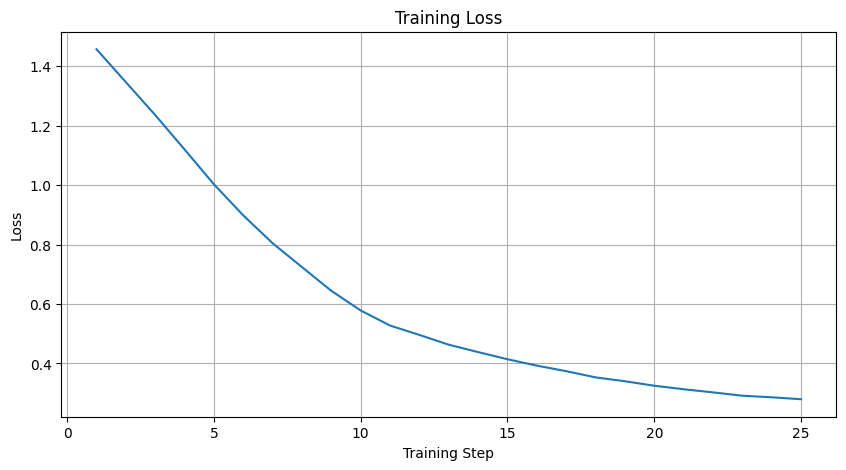

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

logs = pd.DataFrame(trainer.state.log_history)

loss_logs = logs[logs["loss"].notna()]

plt.figure(figsize=(10,5))
plt.plot(loss_logs["step"], loss_logs["loss"])
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

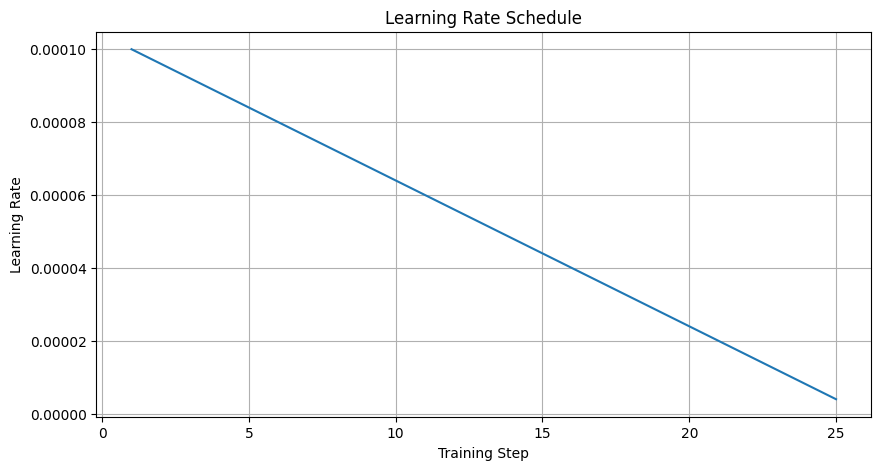

In [39]:
lr_logs = logs[logs["learning_rate"].notna()]

plt.figure(figsize=(10,5))
plt.plot(lr_logs["step"], lr_logs["learning_rate"])
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.grid(True)
plt.show()

In [40]:
metrics = trainer.state.log_history[-1]

for k, v in metrics.items():
    print(f"{k}: {v}")

train_runtime: 20.5587
train_samples_per_second: 1.216
train_steps_per_second: 1.216
total_flos: 11418921216000.0
train_loss: 0.6162230014801026
epoch: 25.0
step: 25


In [41]:
print(trainer.state.log_history[-1])

{'train_runtime': 20.5587, 'train_samples_per_second': 1.216, 'train_steps_per_second': 1.216, 'total_flos': 11418921216000.0, 'train_loss': 0.6162230014801026, 'epoch': 25.0, 'step': 25}
